# Task 6: Policy Evaluation

This notebook first creates the historical input-data CSV, then evaluates the selected policies, creates tables, plots the results, and saves the outputs.

In [49]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from Task6_Environment import run_policy, dummy_action

## 1. Set Up Data File Paths

The environment reads prices and occupancies directly from the three source CSV files ? no intermediate CSV is created.

In [50]:
# Paths to the three source CSV files (same directory as this notebook)
price_csv = Path("v2_PriceData.csv")
occ1_csv  = Path("OccupancyRoom1.csv")
occ2_csv  = Path("OccupancyRoom2.csv")

# Output directory for saved figures
INPUT_OUTPUT_DIR = Path("output")
INPUT_OUTPUT_DIR.mkdir(exist_ok=True)

# Quick sanity check
for p in [price_csv, occ1_csv, occ2_csv]:
    n_rows = len(pd.read_csv(p))
    print(f"?  {p.name}  ?  {n_rows} days")

?  v2_PriceData.csv  ?  100 days
?  OccupancyRoom1.csv  ?  100 days
?  OccupancyRoom2.csv  ?  100 days


---
## 2. Hindsight-Optimal Lower Bound

Solves the **10-step perfect-information MILP** for every day in the same CSV created in Step 1.  
All future prices and occupancies are passed to the solver simultaneously â€” this is the **best possible outcome** any causal policy could ever achieve.

The hindsight-optimal cost is a **provable lower bound**: no policy that observes information sequentially can beat it.

Implementation: `hindsight_optimization.py` (Task 1 formulation from the assignment PDF).

Set `VERBOSE = True` to print the optimal cost for each individual day.

In [51]:
from hindsight_optimization import run_hindsight

VERBOSE = True   # set True to print each day's optimal cost
NUM_DAYS = 100
print(f"Running hindsight-optimal MILP on {NUM_DAYS} days\n")

hindsight_costs, hindsight_details = run_hindsight(
    price_csv, occ1_csv, occ2_csv, verbose=VERBOSE
)

# Summary statistics
valid = hindsight_costs[~np.isnan(hindsight_costs)]
print(f"\nHindsight-Optimal Results ({len(valid)}/{NUM_DAYS} days feasible):")
print(f"  Mean daily cost : {valid.mean():.3f} euro")
print(f"  Std             : {valid.std():.3f} euro")
print(f"  Min             : {valid.min():.3f} euro")
print(f"  Max             : {valid.max():.3f} euro")

Running hindsight-optimal MILP on 100 days

  Day   1/100  |  optimal cost =   96.20 euro  |  prices  [3.03, 7.05]
  Day   2/100  |  optimal cost =  137.71 euro  |  prices  [3.30, 8.65]
  Day   3/100  |  optimal cost =  181.01 euro  |  prices  [4.22, 8.30]
  Day   4/100  |  optimal cost =  108.29 euro  |  prices  [3.30, 5.28]
  Day   5/100  |  optimal cost =  153.05 euro  |  prices  [2.93, 7.22]
  Day   6/100  |  optimal cost =   43.18 euro  |  prices  [0.66, 6.05]
  Day   7/100  |  optimal cost =  207.88 euro  |  prices  [3.37, 12.00]
  Day   8/100  |  optimal cost =  189.14 euro  |  prices  [5.58, 9.64]
  Day   9/100  |  optimal cost =   99.15 euro  |  prices  [1.68, 6.49]
  Day  10/100  |  optimal cost =  142.83 euro  |  prices  [2.72, 7.02]
  Day  11/100  |  optimal cost =   10.98 euro  |  prices  [0.04, 2.40]
  Day  12/100  |  optimal cost =  146.02 euro  |  prices  [0.97, 10.08]
  Day  13/100  |  optimal cost =  180.19 euro  |  prices  [2.18, 10.19]
  Day  14/100  |  optimal cost

---
## 3. Dummy Policy Evaluation (reactive baseline)

The dummy policy takes **no optimisation decisions** it only reacts to mandatory overrule controllers:
- Heats at **P_max** only when `y_low_r = 1` (low-temperature overrule active).
- Ventilates only when `c > 0` (inertia counter) or `H >= H_high` (humidity overrule).

This is the **worst reasonable baseline**: any optimising policy should beat it.

In [52]:
n_days = len(pd.read_csv(price_csv))
print(f"Simulating Dummy policy on {n_days} days ...")
dummy_costs, dummy_times = run_policy(
    dummy_action, price_csv, occ1_csv, occ2_csv,
    policy_name="Dummy (reactive)",
    verbose=True,
)

print(f"\nDummy Policy Results:")
print(f"  Mean daily cost : {dummy_costs.mean():.3f} euro")
print(f"  Std             : {dummy_costs.std():.3f} euro")
print(f"  Min             : {dummy_costs.min():.3f} euro")
print(f"  Max             : {dummy_costs.max():.3f} euro")

Simulating Dummy policy on 100 days ...
  Day   1/100  |  cost =  192.53 euro  |  avg step = 0 ms
  Day   2/100  |  cost =  196.76 euro  |  avg step = 0 ms
  Day   3/100  |  cost =  256.84 euro  |  avg step = 0 ms
  Day   4/100  |  cost =  166.67 euro  |  avg step = 0 ms
  Day   5/100  |  cost =  223.49 euro  |  avg step = 0 ms
  Day   6/100  |  cost =   85.84 euro  |  avg step = 0 ms
  Day   7/100  |  cost =  320.51 euro  |  avg step = 0 ms
  Day   8/100  |  cost =  272.59 euro  |  avg step = 0 ms
  Day   9/100  |  cost =  145.85 euro  |  avg step = 0 ms
  Day  10/100  |  cost =  221.62 euro  |  avg step = 0 ms
  Day  11/100  |  cost =   37.37 euro  |  avg step = 0 ms
  Day  12/100  |  cost =  227.96 euro  |  avg step = 0 ms
  Day  13/100  |  cost =  259.94 euro  |  avg step = 0 ms
  Day  14/100  |  cost =  308.84 euro  |  avg step = 0 ms
  Day  15/100  |  cost =   72.25 euro  |  avg step = 0 ms
  Day  16/100  |  cost =  136.10 euro  |  avg step = 0 ms
  Day  17/100  |  cost =   24.58

---
## 4. SP Policy Evaluation (horizon = 2, branches = 2)

Evaluates the SP policy on the **same 100 days from the CSV** above.  
At each hour the policy receives the current (realized) price and occupancy from the CSV,
builds a 2-stage scenario tree (branching = 2), solves the MILP, and returns the here-and-now action.  
Overrule controllers are applied by the simulator after the policy returns.

In [53]:
import importlib.util, sys

#  Load SP policy 
_sp_path = Path("SP_policy_14.py")
_spec    = importlib.util.spec_from_file_location("SP_policy_14", _sp_path)
_sp_mod  = importlib.util.module_from_spec(_spec)
sys.modules["SP_policy_14"] = _sp_mod
_spec.loader.exec_module(_sp_mod)
sp_select_action = _sp_mod.select_action   # horizon=2, branches=2, n_init=1000

print("SP policy loaded.")
n_days = len(pd.read_csv(price_csv))
print(f"\nSimulating SP policy on {n_days} days ...")

sp_costs, sp_times = run_policy(
    sp_select_action, price_csv, occ1_csv, occ2_csv,
    policy_name="SP (h=2, b=2)",
    verbose=True,
)

print(f"\nSP Policy Results (horizon=2, branches=2):")
print(f"  Mean daily cost : {sp_costs.mean():.3f} euro")
print(f"  Std             : {sp_costs.std():.3f} euro")
print(f"  Min             : {sp_costs.min():.3f} euro")
print(f"  Max             : {sp_costs.max():.3f} euro")

SP policy loaded.

Simulating SP policy on 100 days ...
  Day   1/100  |  cost =  162.44 euro  |  avg step = 28 ms
  Day   2/100  |  cost =  163.91 euro  |  avg step = 28 ms
  Day   3/100  |  cost =  193.19 euro  |  avg step = 27 ms
  Day   4/100  |  cost =  143.04 euro  |  avg step = 28 ms
  Day   5/100  |  cost =  181.28 euro  |  avg step = 27 ms
  Day   6/100  |  cost =   86.56 euro  |  avg step = 28 ms
  Day   7/100  |  cost =  237.78 euro  |  avg step = 27 ms
  Day   8/100  |  cost =  216.26 euro  |  avg step = 28 ms
  Day   9/100  |  cost =  120.83 euro  |  avg step = 37 ms
  Day  10/100  |  cost =  170.11 euro  |  avg step = 28 ms
  Day  11/100  |  cost =   44.39 euro  |  avg step = 28 ms
  Day  12/100  |  cost =  168.00 euro  |  avg step = 28 ms
  Day  13/100  |  cost =  201.97 euro  |  avg step = 27 ms
  Day  14/100  |  cost =  239.17 euro  |  avg step = 27 ms
  Day  15/100  |  cost =   65.52 euro  |  avg step = 28 ms
  Day  16/100  |  cost =  113.28 euro  |  avg step = 27 ms


## 4. Two-stage Policy Evaluation (horizon = 1, branches = 10)

In [54]:
#  Load Two-stage policy 
_sp_path = Path("Two_stage_policy_14.py")
_spec    = importlib.util.spec_from_file_location("Two_stage_policy_14", _sp_path)
_sp_mod  = importlib.util.module_from_spec(_spec)
sys.modules["Two_stage_policy_14"] = _sp_mod
_spec.loader.exec_module(_sp_mod)
sp_select_action = _sp_mod.select_action   # horizon=1, branches=10, n_init=1000

print("SP policy loaded  (horizon=1, branches=10, n_init=1000).")
n_days = len(pd.read_csv(price_csv))
print(f"\nSimulating 2-stage policy on {n_days} days ...")

two_stage_costs, two_stage_times = run_policy(
    sp_select_action, price_csv, occ1_csv, occ2_csv,
    policy_name="2-stage (h=1, b=10)",
    verbose=True,
)

print(f"\n2-stage Policy Results (horizon=1, branches=10):")
print(f"  Mean daily cost : {two_stage_costs.mean():.3f} euro")
print(f"  Std             : {two_stage_costs.std():.3f} euro")
print(f"  Min             : {two_stage_costs.min():.3f} euro")
print(f"  Max             : {two_stage_costs.max():.3f} euro")

SP policy loaded  (horizon=1, branches=10, n_init=1000).

Simulating 2-stage policy on 100 days ...
  Day   1/100  |  cost =  159.51 euro  |  avg step = 36 ms
  Day   2/100  |  cost =  146.66 euro  |  avg step = 35 ms
  Day   3/100  |  cost =  193.19 euro  |  avg step = 45 ms
  Day   4/100  |  cost =  141.88 euro  |  avg step = 34 ms
  Day   5/100  |  cost =  166.78 euro  |  avg step = 34 ms
  Day   6/100  |  cost =   66.65 euro  |  avg step = 35 ms
  Day   7/100  |  cost =  237.78 euro  |  avg step = 35 ms
  Day   8/100  |  cost =  216.26 euro  |  avg step = 44 ms
  Day   9/100  |  cost =  105.98 euro  |  avg step = 35 ms
  Day  10/100  |  cost =  152.97 euro  |  avg step = 35 ms
  Day  11/100  |  cost =   35.31 euro  |  avg step = 34 ms
  Day  12/100  |  cost =  155.95 euro  |  avg step = 34 ms
  Day  13/100  |  cost =  195.85 euro  |  avg step = 43 ms
  Day  14/100  |  cost =  239.17 euro  |  avg step = 35 ms
  Day  15/100  |  cost =   48.76 euro  |  avg step = 34 ms
  Day  16/100  

c:\Users\Alejandro\miniforge3\envs\02435_DMUU\Lib\site-packages\scipy\_lib\_util.py:365: UserWarning: One of the clusters is empty. Re-run kmeans with a different initialization.
  return fun(*args, **kwargs)


  Day  56/100  |  cost =   57.79 euro  |  avg step = 36 ms
  Day  57/100  |  cost =  224.20 euro  |  avg step = 35 ms
  Day  58/100  |  cost =  197.93 euro  |  avg step = 34 ms
  Day  59/100  |  cost =  172.23 euro  |  avg step = 44 ms
  Day  60/100  |  cost =  195.65 euro  |  avg step = 35 ms
  Day  61/100  |  cost =  196.31 euro  |  avg step = 34 ms
  Day  62/100  |  cost =   85.82 euro  |  avg step = 34 ms
  Day  63/100  |  cost =  140.04 euro  |  avg step = 35 ms
  Day  64/100  |  cost =  163.62 euro  |  avg step = 45 ms
  Day  65/100  |  cost =  272.37 euro  |  avg step = 35 ms
  Day  66/100  |  cost =  112.58 euro  |  avg step = 34 ms
  Day  67/100  |  cost =   55.72 euro  |  avg step = 35 ms
  Day  68/100  |  cost =  228.15 euro  |  avg step = 35 ms
  Day  69/100  |  cost =  145.62 euro  |  avg step = 45 ms
  Day  70/100  |  cost =  143.43 euro  |  avg step = 35 ms
  Day  71/100  |  cost =  170.90 euro  |  avg step = 34 ms
  Day  72/100  |  cost =  167.66 euro  |  avg step = 35 

---
## 3. ADP Policy Evaluation (5-feature VFA, pre-trained weights)

Evaluates the ADP policy on the **same 100 days from the CSV**.  
At each hour the policy solves a single-step MILP with the pre-trained linear VFA
(`TRAINED_THETA`) as the approximated future cost â€” no scenario tree required.  
Overrule controllers are applied by the simulator after the policy returns.

In [58]:
import importlib

# Load ADP policy 
_adp_spec = importlib.util.spec_from_file_location("ADP_policy_14", Path("ADP_policy_14.py"))
_adp_mod  = importlib.util.module_from_spec(_adp_spec)
sys.modules["ADP_policy_14"] = _adp_mod
_adp_spec.loader.exec_module(_adp_mod)
adp_select_action = _adp_mod.select_action

print("ADP policy loaded.")
# print(f"TRAINED_THETA = {[round(x, 4) for x in _adp_mod.TRAINED_THETA]}")

n_days = len(pd.read_csv(price_csv))
print(f"\nSimulating ADP policy on {n_days} days ...")
adp_costs, adp_times = run_policy(
    adp_select_action, price_csv, occ1_csv, occ2_csv,
    policy_name="ADP (7-feature VFA)",
    verbose=True,
)

print(f"\nADP Policy Results:")
print(f"  Mean daily cost : {adp_costs.mean():.3f} euro")
print(f"  Std             : {adp_costs.std():.3f} euro")
print(f"  Min             : {adp_costs.min():.3f} euro")
print(f"  Max             : {adp_costs.max():.3f} euro")

[ADP] Loaded 10 timesteps × 11 values (10 weights + 1 intercept)
[ADP]   t=0: [-10.9375 -13.8431  36.845   73.1293   2.3947  -4.0903   0.5568   9.4859
  12.146   10.1705 149.5476]
[ADP]   t=1: [ -9.0631 -15.3237  40.0589  36.116   16.8499  -8.0302   8.4276  13.1752
  14.7025  12.5584 133.3117]
[ADP]   t=2: [-18.2667  -7.5363  38.3771  63.6748   7.0473   0.3101  -3.9885   4.2596
  14.6126  11.4002 104.1526]
ADP policy loaded.

Simulating ADP policy on 100 days ...
  t=0 | p1=2.74 p2=3.00 v=0 | imm=24.749 vfa_curr=192.48 | price=4.31 | T1=21.0 T2=21.0


  t=1 | p1=1.82 p2=2.08 v=0 | imm=13.734 vfa_curr=161.25 | price=3.52 | T1=22.0 T2=21.9
  t=2 | p1=2.32 p2=2.58 v=1 | imm=20.881 vfa_curr=143.41 | price=3.03 | T1=22.0 T2=22.0
  t=3 | p1=2.10 p2=2.31 v=1 | imm=19.757 vfa_curr=120.02 | price=3.08 | T1=22.0 T2=22.0
  t=4 | p1=2.01 p2=2.06 v=1 | imm=20.064 vfa_curr=95.64 | price=3.31 | T1=22.0 T2=22.0
  t=5 | p1=1.30 p2=3.00 v=0 | imm=18.006 vfa_curr=77.09 | price=4.19 | T1=22.0 T2=22.0
  t=6 | p1=0.00 p2=0.00 v=0 | imm=0.000 vfa_curr=65.71 | price=5.47 | T1=22.0 T2=23.7
  t=7 | p1=0.00 p2=0.00 v=0 | imm=0.000 vfa_curr=61.90 | price=6.33 | T1=21.6 T2=21.1
  t=8 | p1=0.00 p2=0.00 v=1 | imm=14.095 vfa_curr=63.85 | price=7.05 | T1=19.8 T2=19.9
  t=9 | p1=3.00 p2=3.00 v=1 | imm=53.699 vfa_curr=52.42 | price=6.71 | T1=17.7 T2=17.5
  Day   1/100  |  cost =  184.99 euro  |  avg step = 22 ms
  t=0 | p1=0.00 p2=0.00 v=0 | imm=0.000 vfa_curr=215.41 | price=7.33 | T1=21.0 T2=21.0
  t=1 | p1=0.00 p2=0.00 v=0 | imm=0.000 vfa_curr=222.41 | price=8.65 |

In [59]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import to_hex
import numpy as np

# ── Collect all results ───────────────────────────────────────────────────────
_all = {
    "Hindsight-Optimal\n(lower bound)": hindsight_costs,
    "SP\n(h=2, b=2)"  : sp_costs,
    "ADP\n(7-feat VFA)": adp_costs,
    #"Hybrid\n(SP+ADP)": hybrid_costs,
    "2-stage (h=1, b=10)": two_stage_costs,  
    "Dummy\n(reactive)": dummy_costs,
}
_colors = {
    "Hindsight-Optimal\n(lower bound)": "#55A868",
    "SP\n(h=2, b=2)"  : "#4C72B0",
    "ADP\n(7-feat VFA)": "#DD8452",
    #"Hybrid\n(SP+ADP)": "#9467BD",
    "2-stage (h=1, b=10)": "#8C564B",
    "Dummy\n(reactive)": "#C44E52",
}

valid_h = hindsight_costs[~np.isnan(hindsight_costs)]

# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for name, arr in _all.items():
    v = arr[~np.isnan(arr)]
    gap = (v.mean() - valid_h.mean()) / valid_h.mean() * 100
    rows.append({
        "Policy":              name.replace("\n", " "),
        "Mean (euro)":         round(v.mean(), 2),
        "Std (euro)":          round(v.std(),  2),
        "Min (euro)":          round(v.min(),  2),
        "Max (euro)":          round(v.max(),  2),
        "Gap to Optimal (%)":  round(gap, 1),
    })

summary_df = pd.DataFrame(rows).sort_values("Mean (euro)").reset_index(drop=True)

# ── Custom coloring function for gap column gradient ────────────────────────────
hindsight_mean = valid_h.mean()
dummy_mean = dummy_costs[~np.isnan(dummy_costs)].mean()
dummy_gap = (dummy_mean - hindsight_mean) / hindsight_mean * 100

def color_gap(val):
    """
    Color mapping for Gap to Optimal:
    • gap = 0% (optimal)        → Bright GREEN (0.1, 0.95, 0.2)
    • gap = 50% of dummy_gap    → Green-Yellow blend
    • gap = dummy_gap% (dummy)  → BRIGHT YELLOW (1.0, 1.0, 0.0)
    • gap > dummy_gap%          → DARK RED (#8B0000)
    """
    if val > dummy_gap:
        return "background-color: #8B0000"  # Dark red for worse than dummy
    else:
        # Normalize gap to [0, 1] where 0 = optimal, 1 = dummy_gap
        ratio = val / dummy_gap if dummy_gap > 0 else 0
        ratio = np.clip(ratio, 0, 1)
        
        # Linear interpolation: DARK GREEN (0.0, 0.5, 0.1) → DARK YELLOW (0.7, 0.6, 0.0)
        r = 0.0 + ratio * (0.7 - 0.0)      # Dark Green R→ Dark Yellow R
        g = 0.5 + ratio * (0.6 - 0.5)      # Dark Green G→ Dark Yellow G
        b = 0.1 + ratio * (0.0 - 0.1)      # Dark Green B→ Dark Yellow B (fades to 0)
        
        return f"background-color: {to_hex((r, g, b))}"

display(summary_df.style
    .map(color_gap, subset=['Gap to Optimal (%)'])
    .format({"Mean (euro)": "{:.2f}", "Std (euro)": "{:.2f}",
             "Min (euro)":  "{:.2f}", "Max (euro)": "{:.2f}",
             "Gap to Optimal (%)": "{:.1f}"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color","#3949AB"),("color","white"),
                                     ("font-size","13px"),("text-align","left")]},
        {"selector": "td", "props": [("font-size","12px"),("padding","5px 12px")]},
    ])
    .hide(axis="index")
)

Policy,Mean (euro),Std (euro),Min (euro),Max (euro),Gap to Optimal (%)
Hindsight-Optimal (lower bound),117.71,58.36,5.78,248.25,0.0
"2-stage (h=1, b=10)",145.02,57.89,17.71,286.15,23.2
"SP (h=2, b=2)",150.98,54.82,23.74,286.15,28.3
Dummy (reactive),183.05,76.68,24.58,368.23,55.5
ADP (7-feat VFA),185.51,76.69,46.51,368.23,57.6


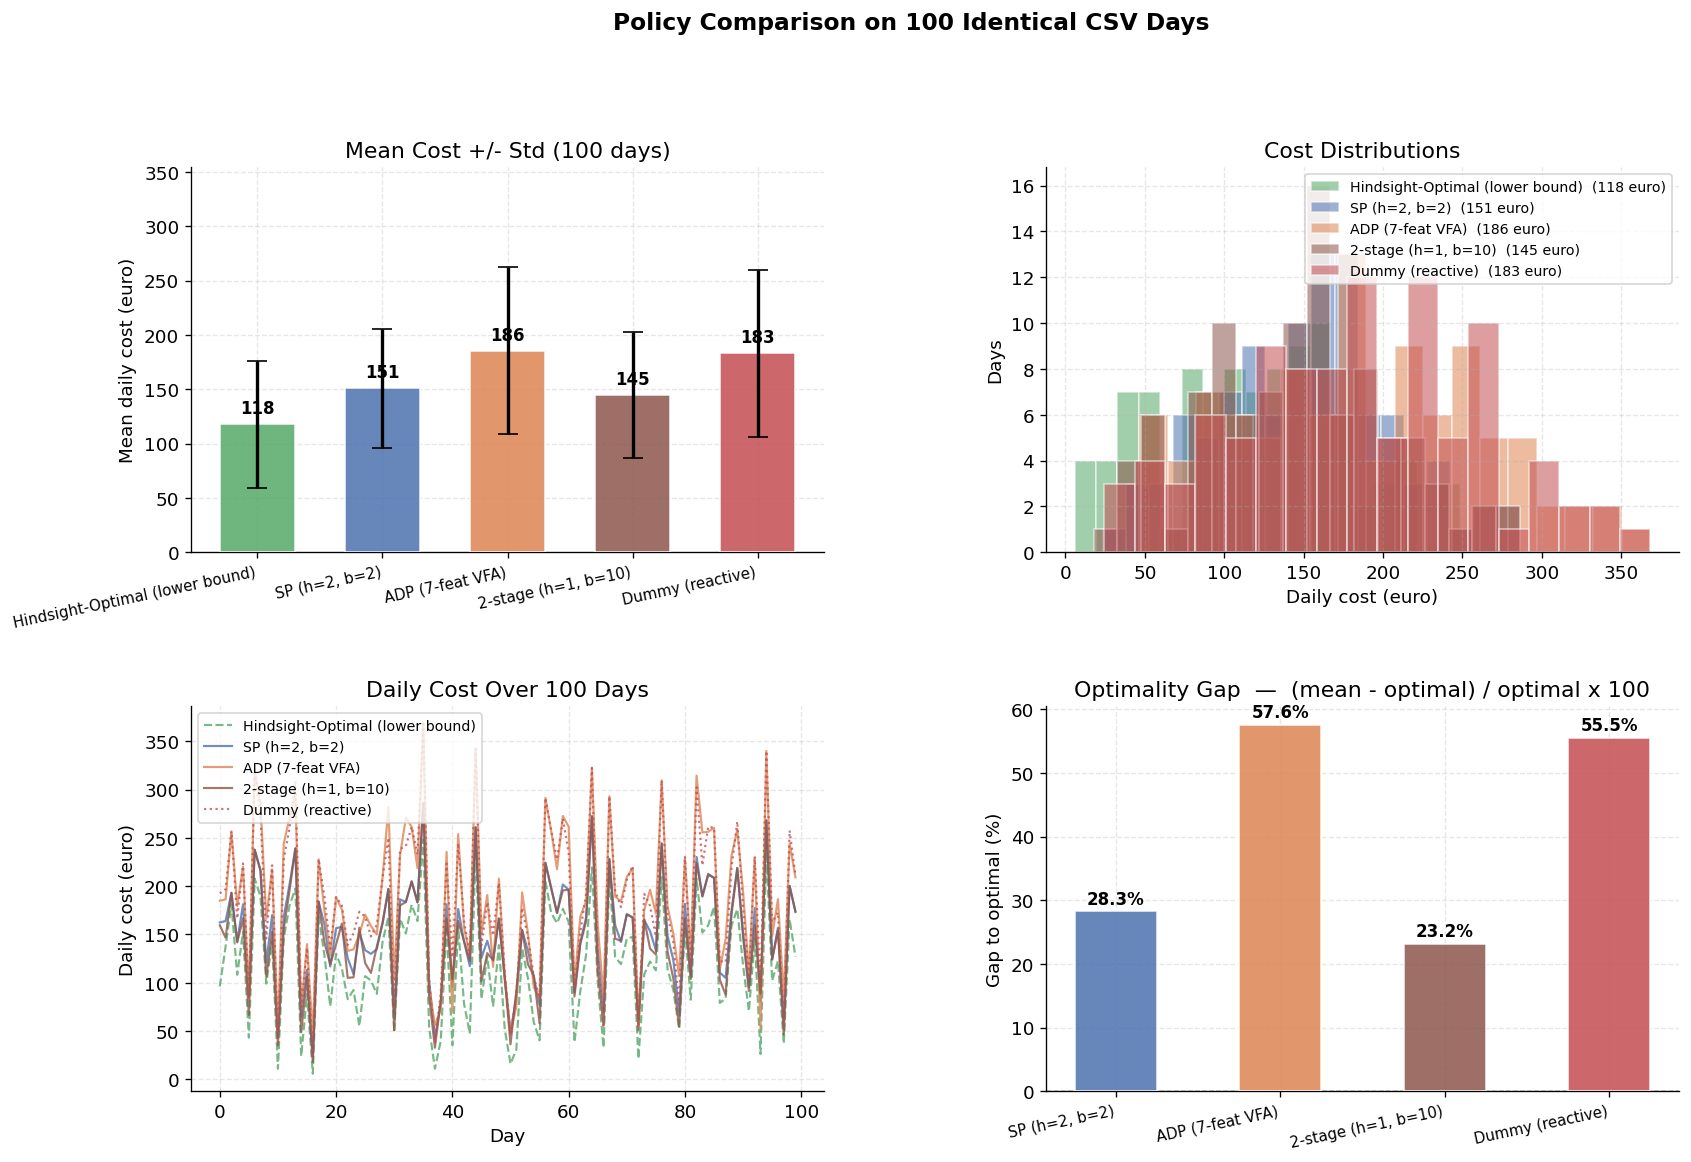

Saved -> output\all_policies_comparison.png


In [60]:
plt.rcParams.update({"figure.dpi": 120, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.3, "grid.linestyle": "--"})

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

names  = list(_all.keys())
arrays = list(_all.values())
cols   = [_colors[n] for n in names]
days   = np.arange(len(sp_costs))

# ── Top-left: mean +/- std bar chart ─────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
x = np.arange(len(names))
means = [arr[~np.isnan(arr)].mean() for arr in arrays]
stds  = [arr[~np.isnan(arr)].std()  for arr in arrays]
bars  = ax.bar(x, means, yerr=stds, capsize=6, color=cols,
               alpha=0.85, edgecolor="white", width=0.6, zorder=3,
               error_kw={"elinewidth": 2, "ecolor": "black"})
for bar, val in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(stds)*0.08,
            f"{val:.0f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels([n.replace("\n", " ") for n in names], rotation=12, ha="right", fontsize=9)
ax.set_ylabel("Mean daily cost (euro)")
ax.set_title("Mean Cost +/- Std (100 days)")
ax.set_ylim(0, max(means) + max(stds) * 2.2)

# ── Top-right: overlapping distributions ─────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
for name, arr, col in zip(names, arrays, cols):
    v = arr[~np.isnan(arr)]
    ax.hist(v, bins=18, alpha=0.55, color=col, edgecolor="white",
            label=f"{name.replace(chr(10),' ')}  ({v.mean():.0f} euro)")
ax.set_xlabel("Daily cost (euro)")
ax.set_ylabel("Days")
ax.set_title("Cost Distributions")
ax.legend(fontsize=8.5)

# ── Bottom-left: per-day timeline ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ls_map = {
    "Hindsight-Optimal\n(lower bound)": "--",
    "SP\n(h=2, b=2)"  : "-",
    "ADP\n(11-feat VFA)": "-",
    "Hybrid\n(SP+ADP)": "-.",
    "Dummy\n(reactive)": ":",
}
for name, arr, col in zip(names, arrays, cols):
    ax.plot(days, arr, color=col, lw=1.3, alpha=0.8,
            linestyle=ls_map.get(name, "-"),
            label=name.replace("\n", " "))
ax.set_xlabel("Day")
ax.set_ylabel("Daily cost (euro)")
ax.set_title("Daily Cost Over 100 Days")
ax.legend(fontsize=8.5)

# ── Bottom-right: gap to optimal ─────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
gap_names  = [n for n in names if "Hindsight" not in n]
gap_values = [(arrays[names.index(n)][~np.isnan(arrays[names.index(n)])].mean()
               - valid_h.mean()) / valid_h.mean() * 100
              for n in gap_names]
gap_colors = [_colors[n] for n in gap_names]
x2 = np.arange(len(gap_names))
gbars = ax.bar(x2, gap_values, color=gap_colors, alpha=0.85,
               edgecolor="white", width=0.5, zorder=3)
for bar, val in zip(gbars, gap_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_xticks(x2)
ax.set_xticklabels([n.replace("\n", " ") for n in gap_names], rotation=12, ha="right", fontsize=9)
ax.set_ylabel("Gap to optimal (%)")
ax.set_title("Optimality Gap  —  (mean - optimal) / optimal x 100")
ax.axhline(0, color="black", lw=0.8, ls="--")

plt.suptitle("Policy Comparison on 100 Identical CSV Days",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig(INPUT_OUTPUT_DIR / "all_policies_comparison.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved -> {INPUT_OUTPUT_DIR / 'all_policies_comparison.png'}")